# BioOptima — Full analysis notebook

Single notebook for thesis / report: **physics check → EDA → ML training & literature validation**.

| Part | Content |
|------|----------|
| **1** | ADM1 sanity check (baseline, stress, temperature, feed mix) |
| **2** | Exploratory data analysis on merged training CSV (~4700 rows) |
| **3** | Model comparison, SHAP, learning curve, literature parity |

**Colab:** run the mount cell, then **Run all**. **Local:** skip mount cell, open from project root or `notebooks/`.

Sweep generation stays in `00_generate_sweep_colab.ipynb` (GPU/time on Colab).

In [ ]:
# Colab only — skip when running locally in Jupyter
import os
import sys

try:
    from google.colab import drive
except ImportError:
    print("Not Colab — skip this cell.")
else:
    drive.mount("/content/drive")
    MY_DRIVE = "/content/drive/MyDrive"
    PROJECT_ROOT = ""  # e.g. "/content/drive/MyDrive/major_project"

    def _is_root(p):
        return os.path.isdir(p) and os.path.isdir(os.path.join(p, "src"))

    if not PROJECT_ROOT or not _is_root(PROJECT_ROOT):
        from collections import deque

        found, q = None, deque([(MY_DRIVE, 0)])
        while q and not found:
            p, d = q.popleft()
            if d > 5:
                continue
            if _is_root(p):
                found = p
                break
            if os.path.isdir(p):
                for name in os.listdir(p):
                    c = os.path.join(p, name)
                    if not name.startswith(".") and os.path.isdir(c):
                        q.append((c, d + 1))
        if not found:
            raise FileNotFoundError(
                "Set PROJECT_ROOT to your Drive folder containing src/"
            )
        PROJECT_ROOT = found
        print("Auto-detected:", PROJECT_ROOT)
    os.chdir(PROJECT_ROOT)
    if PROJECT_ROOT not in sys.path:
        sys.path.insert(0, PROJECT_ROOT)
    print("OK — CWD:", os.getcwd())


In [ ]:
import importlib.util
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    mean_squared_error,
    r2_score,
    accuracy_score,
)
from sklearn.model_selection import train_test_split

ROOT = Path.cwd()
if not (ROOT / "src").is_dir() and (ROOT.parent / "src").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import features as feat_mod
from src import health_utils
from src import simulator
from src.calibration import (
    UI_HRT_MAX,
    UI_HRT_MIN,
    UI_OLR_MAX,
    UI_OLR_MIN,
    UI_TEMP_MAX,
    UI_TEMP_MIN,
)

_spec = importlib.util.spec_from_file_location(
    "train_models", ROOT / "scripts" / "train_models.py"
)
tm = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(tm)

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True})

SEED = 42
CV_FOLDS = 5
V_LIQ = 100.0
SKIP_STACKING_CV = True  # merge stacking metrics from model_comparison.json
CSV_PATH = ROOT / "data" / "generated" / "biogas_training_merged.csv"

print("Project root:", ROOT)
print("Training CSV:", CSV_PATH.name)


---

# Part 1 — ADM1 physics sanity check

Verify **PyADM1ODE** before trusting sweep data. Each run ~15–60 s.

Checks: convergence, overload (VFA/pH), temperature response, substrate quality.

## 1. Baseline run (cow-dung-heavy mix, mesophilic)

In [2]:
BASE_MIX = np.array([0.5, 0.1, 0.05, 0.15, 0.1, 0.1], dtype=float)
BASE_MIX /= BASE_MIX.sum()
HRT_BASE = 25.0
TEMP_BASE = 35.0
SIM_DAYS = 30

t0 = time.perf_counter()
baseline = simulator.run_from_hrt_mix(
    BASE_MIX,
    temp_C=TEMP_BASE,
    HRT=HRT_BASE,
    sim_days=SIM_DAYS,
)
elapsed = time.perf_counter() - t0

print(f"Wall time: {elapsed:.1f} s")
print(f"Converged: {baseline['converged']}")
print(f"Achieved OLR: {baseline.get('OLR', baseline.get('OLR_used', 0)):.2f} kg VS/m³/d")
print(f"CH₄ (last-week avg): {baseline['q_ch4_avg']:.2f} m³/d")
print(f"Final pH: {baseline['pH_final']:.2f}, VFA: {baseline['VFA_final']:.2f} kg/m³")
print(f"Stability: {health_utils.stability_name(health_utils.classify_stability(baseline['pH_final'], baseline['VFA_final']))}")

Wall time: 1.5 s
Converged: True
Achieved OLR: 4.41 kg VS/m³/d
CH₄ (last-week avg): 54.26 m³/d
Final pH: 7.31, VFA: 0.10 kg/m³
Stability: Stable


## 2. Overload vs baseline (short HRT → higher loading stress)

Stress run: 0.6 s, OLR=11.02, CH₄=87.74


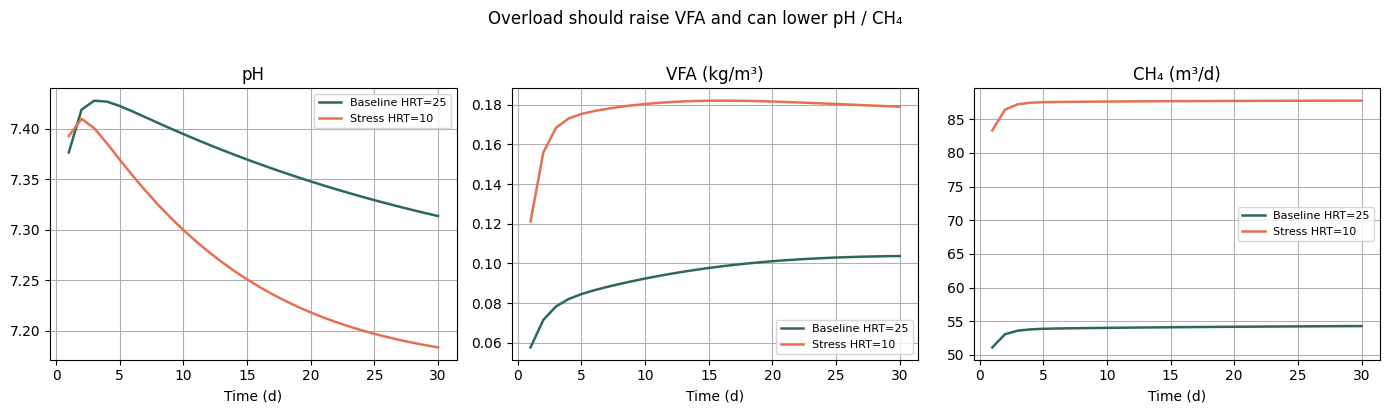

In [3]:
HRT_STRESS = 10.0

t0 = time.perf_counter()
stressed = simulator.run_from_hrt_mix(
    BASE_MIX,
    temp_C=TEMP_BASE,
    HRT=HRT_STRESS,
    sim_days=SIM_DAYS,
)
print(f"Stress run: {time.perf_counter() - t0:.1f} s, OLR={stressed.get('OLR', 0):.2f}, CH₄={stressed['q_ch4_avg']:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(axes, ["pH", "VFA", "q_ch4"], ["pH", "VFA (kg/m³)", "CH₄ (m³/d)"]):
    for label, out, color in [("Baseline HRT=25", baseline, "#2d6a4f"), ("Stress HRT=10", stressed, "#e76f51")]:
        ts = out["time_series"]
        if ts is None or getattr(ts, "empty", True):
            continue
        ax.plot(ts["time_d"], ts[col], label=label, color=color, lw=1.8)
    ax.set_title(title)
    ax.set_xlabel("Time (d)")
    ax.legend(fontsize=8)
plt.suptitle("Overload should raise VFA and can lower pH / CH₄", y=1.02)
plt.tight_layout()
plt.show()

## 3. Temperature sensitivity (28 / 35 / 42 °C)

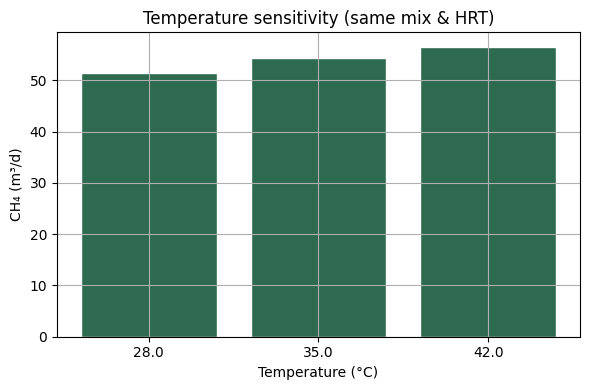

,temp_C,q_ch4,pH,VFA
0,28.0,51.360,7.246,0.136
1,35.0,54.256,7.314,0.104
2,42.0,56.523,7.383,0.085


In [4]:
temp_results = []
for temp in [28.0, 35.0, 42.0]:
    out = simulator.run_from_hrt_mix(BASE_MIX, temp_C=temp, HRT=HRT_BASE, sim_days=SIM_DAYS)
    temp_results.append({"temp_C": temp, "q_ch4": out["q_ch4_avg"], "pH": out["pH_final"], "VFA": out["VFA_final"]})

tdf = pd.DataFrame(temp_results)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(tdf["temp_C"].astype(str), tdf["q_ch4"], color="#2d6a4f", edgecolor="white")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("CH₄ (m³/d)")
ax.set_title("Temperature sensitivity (same mix & HRT)")
plt.tight_layout()
plt.show()
display(tdf.round(3))

## 4. Feed composition sensitivity

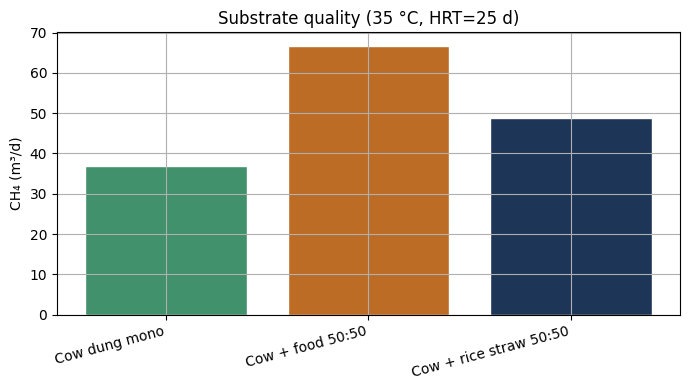

,scenario,q_ch4,pH,VFA,OLR
0,Cow dung mono,36.946,7.307,0.082,3.680
1,Cow + food 50:50,66.721,7.382,0.199,4.332
2,Cow + rice straw 50:50,48.815,7.197,0.056,4.865


In [5]:
scenarios = {
    "Cow dung mono": np.array([1, 0, 0, 0, 0, 0], dtype=float),
    "Cow + food 50:50": np.array([0.5, 0, 0, 0.5, 0, 0], dtype=float),
    "Cow + rice straw 50:50": np.array([0.5, 0.5, 0, 0, 0, 0], dtype=float),
}
feed_rows = []
for name, vf in scenarios.items():
    vf = vf / vf.sum()
    out = simulator.run_from_hrt_mix(vf, temp_C=TEMP_BASE, HRT=HRT_BASE, sim_days=SIM_DAYS)
    feed_rows.append({
        "scenario": name,
        "q_ch4": out["q_ch4_avg"],
        "pH": out["pH_final"],
        "VFA": out["VFA_final"],
        "OLR": out.get("OLR", np.nan),
    })

fdf = pd.DataFrame(feed_rows)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(fdf["scenario"], fdf["q_ch4"], color=["#40916c", "#bc6c25", "#1d3557"], edgecolor="white")
ax.set_ylabel("CH₄ (m³/d)")
ax.set_title("Substrate quality (35 °C, HRT=25 d)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()
display(fdf.round(3))

## 5. Summary table (all runs)

In [6]:
summary = [
    {"scenario": "Baseline", "temp_C": TEMP_BASE, "HRT_d": HRT_BASE, **{k: baseline[k] for k in ['q_ch4_avg', 'pH_final', 'VFA_final', 'converged']}},
    {"scenario": "Stress HRT", "temp_C": TEMP_BASE, "HRT_d": HRT_STRESS, **{k: stressed[k] for k in ['q_ch4_avg', 'pH_final', 'VFA_final', 'converged']}},
]
for _, r in tdf.iterrows():
    summary.append({"scenario": f"T={r['temp_C']:.0f}C", "temp_C": r["temp_C"], "HRT_d": HRT_BASE, "q_ch4_avg": r["q_ch4"], "pH_final": r["pH"], "VFA_final": r["VFA"], "converged": True})
for _, r in fdf.iterrows():
    summary.append({"scenario": r["scenario"], "temp_C": TEMP_BASE, "HRT_d": HRT_BASE, "q_ch4_avg": r["q_ch4"], "pH_final": r["pH"], "VFA_final": r["VFA"], "converged": True})

summary_df = pd.DataFrame(summary)
display(summary_df.round(3))

,scenario,temp_C,HRT_d,q_ch4_avg,pH_final,VFA_final,converged
0,Baseline,35.0,25.0,54.256,7.314,0.104,True
1,Stress HRT,35.0,10.0,87.735,7.184,0.179,True
2,T=28C,28.0,25.0,51.360,7.246,0.136,True
3,T=35C,35.0,25.0,54.256,7.314,0.104,True
4,T=42C,42.0,25.0,56.523,7.383,0.085,True
5,Cow dung mono,35.0,25.0,36.946,7.307,0.082,True
6,Cow + food 50:50,35.0,25.0,66.721,7.382,0.199,True
7,Cow + rice straw 50:50,35.0,25.0,48.815,7.197,0.056,True


## Conclusion

If the plots above show:
- **Higher temperature** → generally higher CH₄ (mesophilic band),
- **Shorter HRT / stress** → higher VFA and/or lower pH vs baseline,
- **Food-waste blends** → higher yield than straw-heavy blends,

then ADM1 behaviour is qualitatively consistent and the **HRT-first sweep** in notebook `00` is safe to use for training data.

---

# Part 2 — Exploratory data analysis

Merged training file: `biogas_training_merged.csv` (main + low-OLR + instability sweeps).

In [2]:
raw = pd.read_csv(CSV_PATH)
if "OLR" not in raw.columns and "OLR_used" in raw.columns:
    raw["OLR"] = raw["OLR_used"]

df = raw[raw["converged"] == True].copy()
df = df[df["stability_label"] >= 0].copy()
print(f"Total rows: {len(raw)}, converged & valid: {len(df)}")
if "OLR" in df.columns:
    print(f"OLR range: {df['OLR'].min():.2f} – {df['OLR'].max():.2f}")
df.head()


Total rows: 4700, converged & valid: 4700
OLR range: 1.74 – 14.90


,idx,cow_frac,rice_frac,wheat_frac,food_frac,press_frac,poultry_frac,temperature_C,HRT_days,OLR,...,q_ch4_avg,pH_final,VFA_final,S_nh3_final,vfa_slope_last5d,ph_slope_last5d,first_instability_day,sim_error,stability_label,sweep_source
0,0,0.135180,0.052338,0.510015,0.108368,0.004933,0.189166,40.479121,27.555138,4.925267,...,64.761153,7.309785,0.064919,0.002275,0.000088,-0.004067,-1,NaN,0,biogas_training_data.csv
1,1,0.093187,0.026085,0.586702,0.060690,0.053938,0.179398,42.171958,37.894721,3.734598,...,53.842583,7.356929,0.050736,0.002554,0.000284,-0.003596,-1,NaN,0,biogas_training_data.csv
2,2,0.107337,0.216462,0.035892,0.219120,0.102925,0.318264,26.883547,49.024894,2.522611,...,42.132887,7.332185,0.174615,0.001300,0.001869,-0.001723,-1,NaN,0,biogas_training_data.csv
3,3,0.160353,0.269558,0.106339,0.095761,0.340493,0.027496,40.222794,41.442572,3.388420,...,50.485309,7.365077,0.045946,0.001940,0.000334,-0.003227,-1,NaN,0,biogas_training_data.csv
4,4,0.486093,0.039551,0.311446,0.119596,0.029482,0.013833,27.562273,28.015438,4.198237,...,48.019793,7.204685,0.088710,0.000670,-0.000090,-0.004258,-1,NaN,0,biogas_training_data.csv


## 1. Target distributions

C:\Users\nikhi\AppData\Local\Temp\ipykernel_17804\1911737967.py:10: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\nikhi\AppData\Local\Temp\ipykernel_17804\1911737967.py:10: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\nikhi\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\nikhi\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


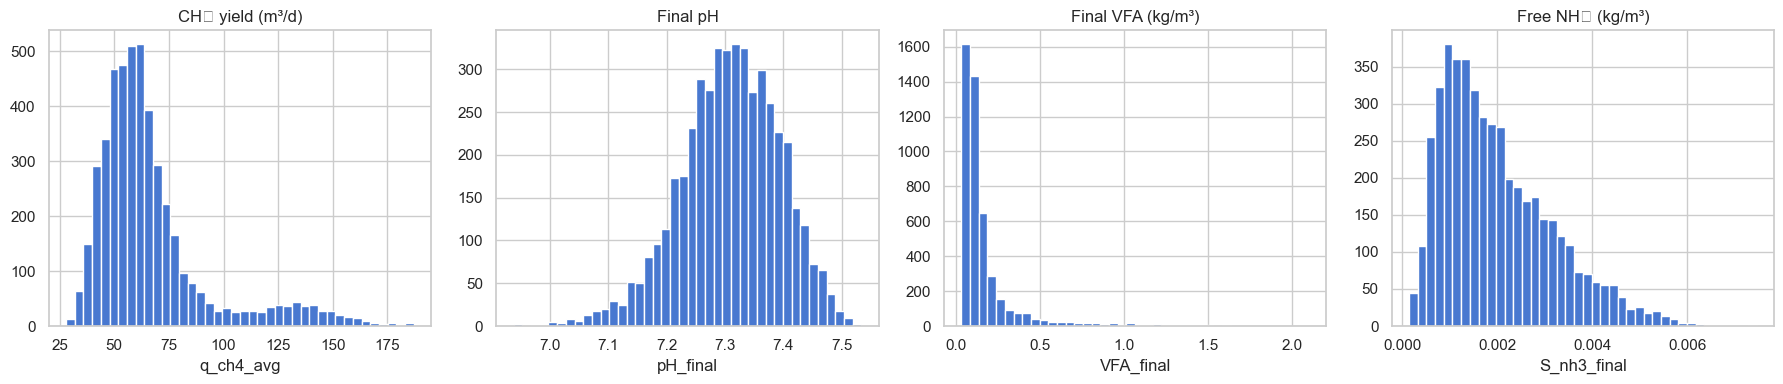

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col, title in zip(
    axes,
    ["q_ch4_avg", "pH_final", "VFA_final", "S_nh3_final"],
    ["CH₄ yield (m³/d)", "Final pH", "Final VFA (kg/m³)", "Free NH₃ (kg/m³)"],
):
    ax.hist(df[col].dropna(), bins=40, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

## 2. Class balance (stability labels)

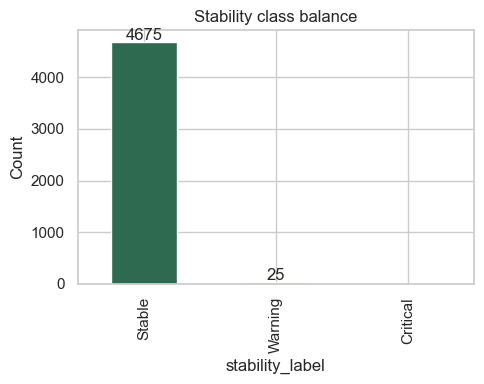

In [4]:
label_map = {0: "Stable", 1: "Warning", 2: "Critical"}
counts = df["stability_label"].map(label_map).value_counts().reindex(["Stable", "Warning", "Critical"])
fig, ax = plt.subplots(figsize=(5, 4))
counts.plot.bar(ax=ax, color=["#2d6a4f", "#e9c46a", "#e76f51"])
ax.set_title("Stability class balance")
ax.set_ylabel("Count")
for i, v in enumerate(counts):
    if pd.notna(v):
        ax.text(i, v + max(counts.max() * 0.01, 1), str(int(v)), ha="center")
plt.tight_layout()
plt.show()

## 3. OLR distribution & UI slider coverage

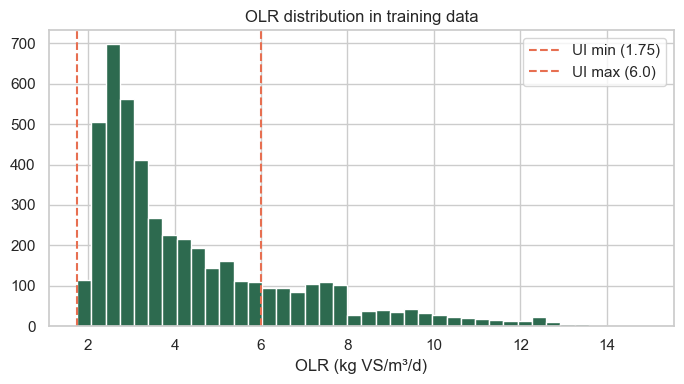

OLR min/max: 1.74 / 14.90
Rows in UI OLR band [1.75, 6.0]: 79.0%


In [5]:
olr = df["OLR"] if "OLR" in df.columns else df.get("OLR_used", pd.Series(dtype=float))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(olr.dropna(), bins=40, color="#2d6a4f", edgecolor="white")
ax.axvline(UI_OLR_MIN, color="#e76f51", ls="--", label=f"UI min ({UI_OLR_MIN})")
ax.axvline(UI_OLR_MAX, color="#e76f51", ls="--", label=f"UI max ({UI_OLR_MAX})")
ax.set_xlabel("OLR (kg VS/m³/d)")
ax.set_title("OLR distribution in training data")
ax.legend()
plt.tight_layout()
plt.show()

in_ui = ((olr >= UI_OLR_MIN) & (olr <= UI_OLR_MAX)).mean() * 100
print(f"OLR min/max: {olr.min():.2f} / {olr.max():.2f}")
print(f"Rows in UI OLR band [{UI_OLR_MIN}, {UI_OLR_MAX}]: {in_ui:.1f}%")

## 4. Training range vs UI slider range

In [6]:
UI_RANGES = {
    "temperature_C": (UI_TEMP_MIN, UI_TEMP_MAX),
    "HRT_days": (UI_HRT_MIN, UI_HRT_MAX),
    "OLR": (UI_OLR_MIN, UI_OLR_MAX),
}

rows = []
for feat, (ui_lo, ui_hi) in UI_RANGES.items():
    if feat not in df.columns:
        continue
    col = df[feat]
    in_band = ((col >= ui_lo) & (col <= ui_hi)).mean() * 100
    rows.append({
        "feature": feat,
        "train_min": col.min(),
        "train_max": col.max(),
        "UI_min": ui_lo,
        "UI_max": ui_hi,
        "coverage_pct": round(in_band, 1),
    })
range_df = pd.DataFrame(rows)
display(range_df.round(3))

,feature,train_min,train_max,UI_min,UI_max,coverage_pct
0,temperature_C,25.011,44.995,25.00,42.0,90.3
1,HRT_days,10.000,49.989,10.00,50.0,100.0
2,OLR,1.745,14.899,1.75,6.0,79.0


## 5. Feature engineering + correlation heatmap

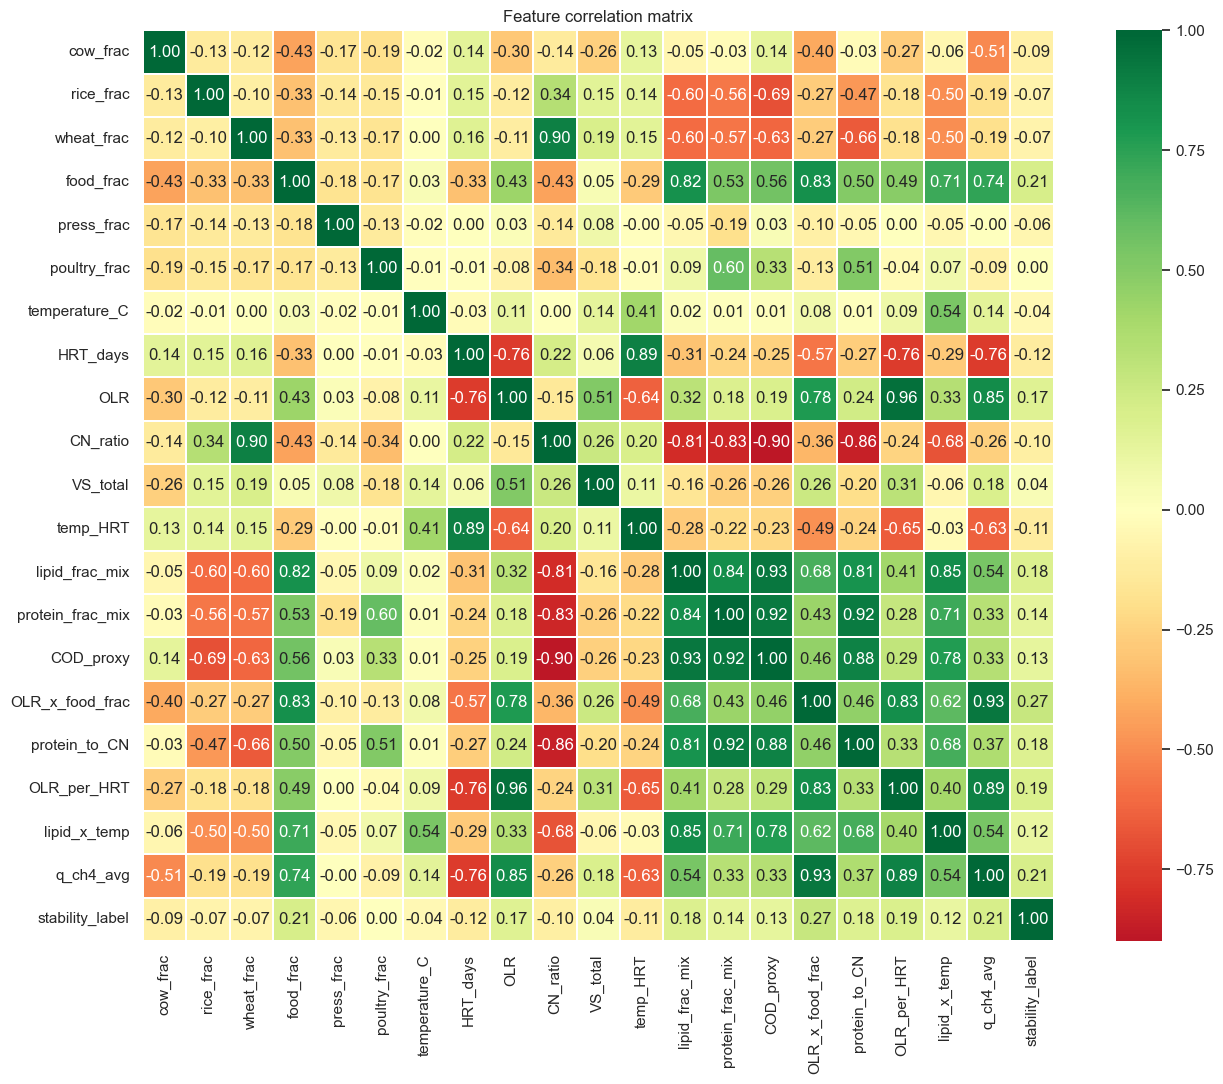

In [7]:
X = feat_mod.dataframe_features(df)
X["q_ch4_avg"] = df["q_ch4_avg"].values
X["stability_label"] = df["stability_label"].values

corr = X.corr()
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax, square=True, linewidths=0.3)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

## 6. Key feature vs target scatters

C:\Users\nikhi\AppData\Local\Temp\ipykernel_17804\3684785008.py:24: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\nikhi\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


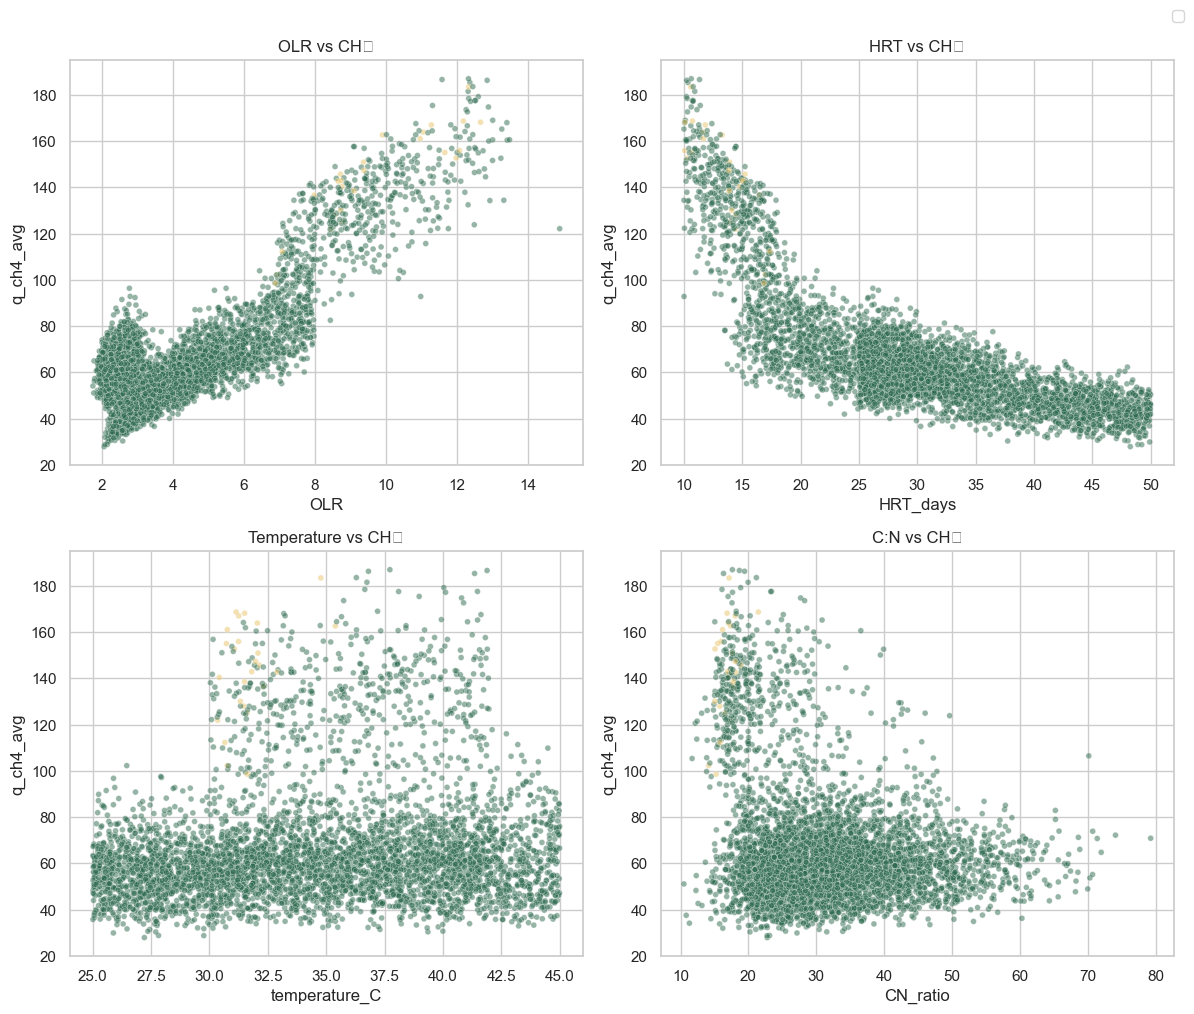

In [8]:
label_map = {0: "Stable", 1: "Warning", 2: "Critical"}
plot_df = df.copy()
plot_df["stability_name"] = plot_df["stability_label"].map(label_map)
if "CN_ratio" not in plot_df.columns:
    plot_df["CN_ratio"] = X["CN_ratio"].values

pairs = [
    ("OLR", "q_ch4_avg", "OLR vs CH₄"),
    ("HRT_days", "q_ch4_avg", "HRT vs CH₄"),
    ("temperature_C", "q_ch4_avg", "Temperature vs CH₄"),
    ("CN_ratio", "q_ch4_avg", "C:N vs CH₄"),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (xcol, ycol, title) in zip(axes.ravel(), pairs):
    sns.scatterplot(
        data=plot_df, x=xcol, y=ycol, hue="stability_name",
        hue_order=["Stable", "Warning", "Critical"],
        palette={"Stable": "#2d6a4f", "Warning": "#e9c46a", "Critical": "#e76f51"},
        alpha=0.5, s=18, ax=ax, legend=False,
    )
    ax.set_title(title)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.0, 1.02), ncol=3)
plt.tight_layout()
plt.show()

## 7. VFA vs pH (classification boundaries)

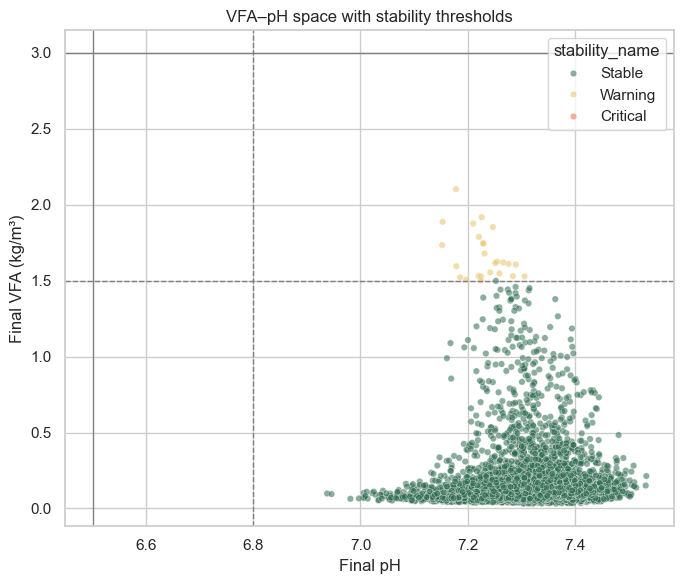

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    data=plot_df, x="pH_final", y="VFA_final", hue="stability_name",
    hue_order=["Stable", "Warning", "Critical"],
    palette={"Stable": "#2d6a4f", "Warning": "#e9c46a", "Critical": "#e76f51"},
    alpha=0.55, s=22, ax=ax,
)
for x, ls in [(6.5, "-"), (6.8, "--")]:
    ax.axvline(x, color="gray", ls=ls, lw=1)
for y, ls in [(1.5, "--"), (3.0, "-")]:
    ax.axhline(y, color="gray", ls=ls, lw=1)
ax.set_xlabel("Final pH")
ax.set_ylabel("Final VFA (kg/m³)")
ax.set_title("VFA–pH space with stability thresholds")
plt.tight_layout()
plt.show()

## 8. Pairplot (key features vs CH₄)

C:\Users\nikhi\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


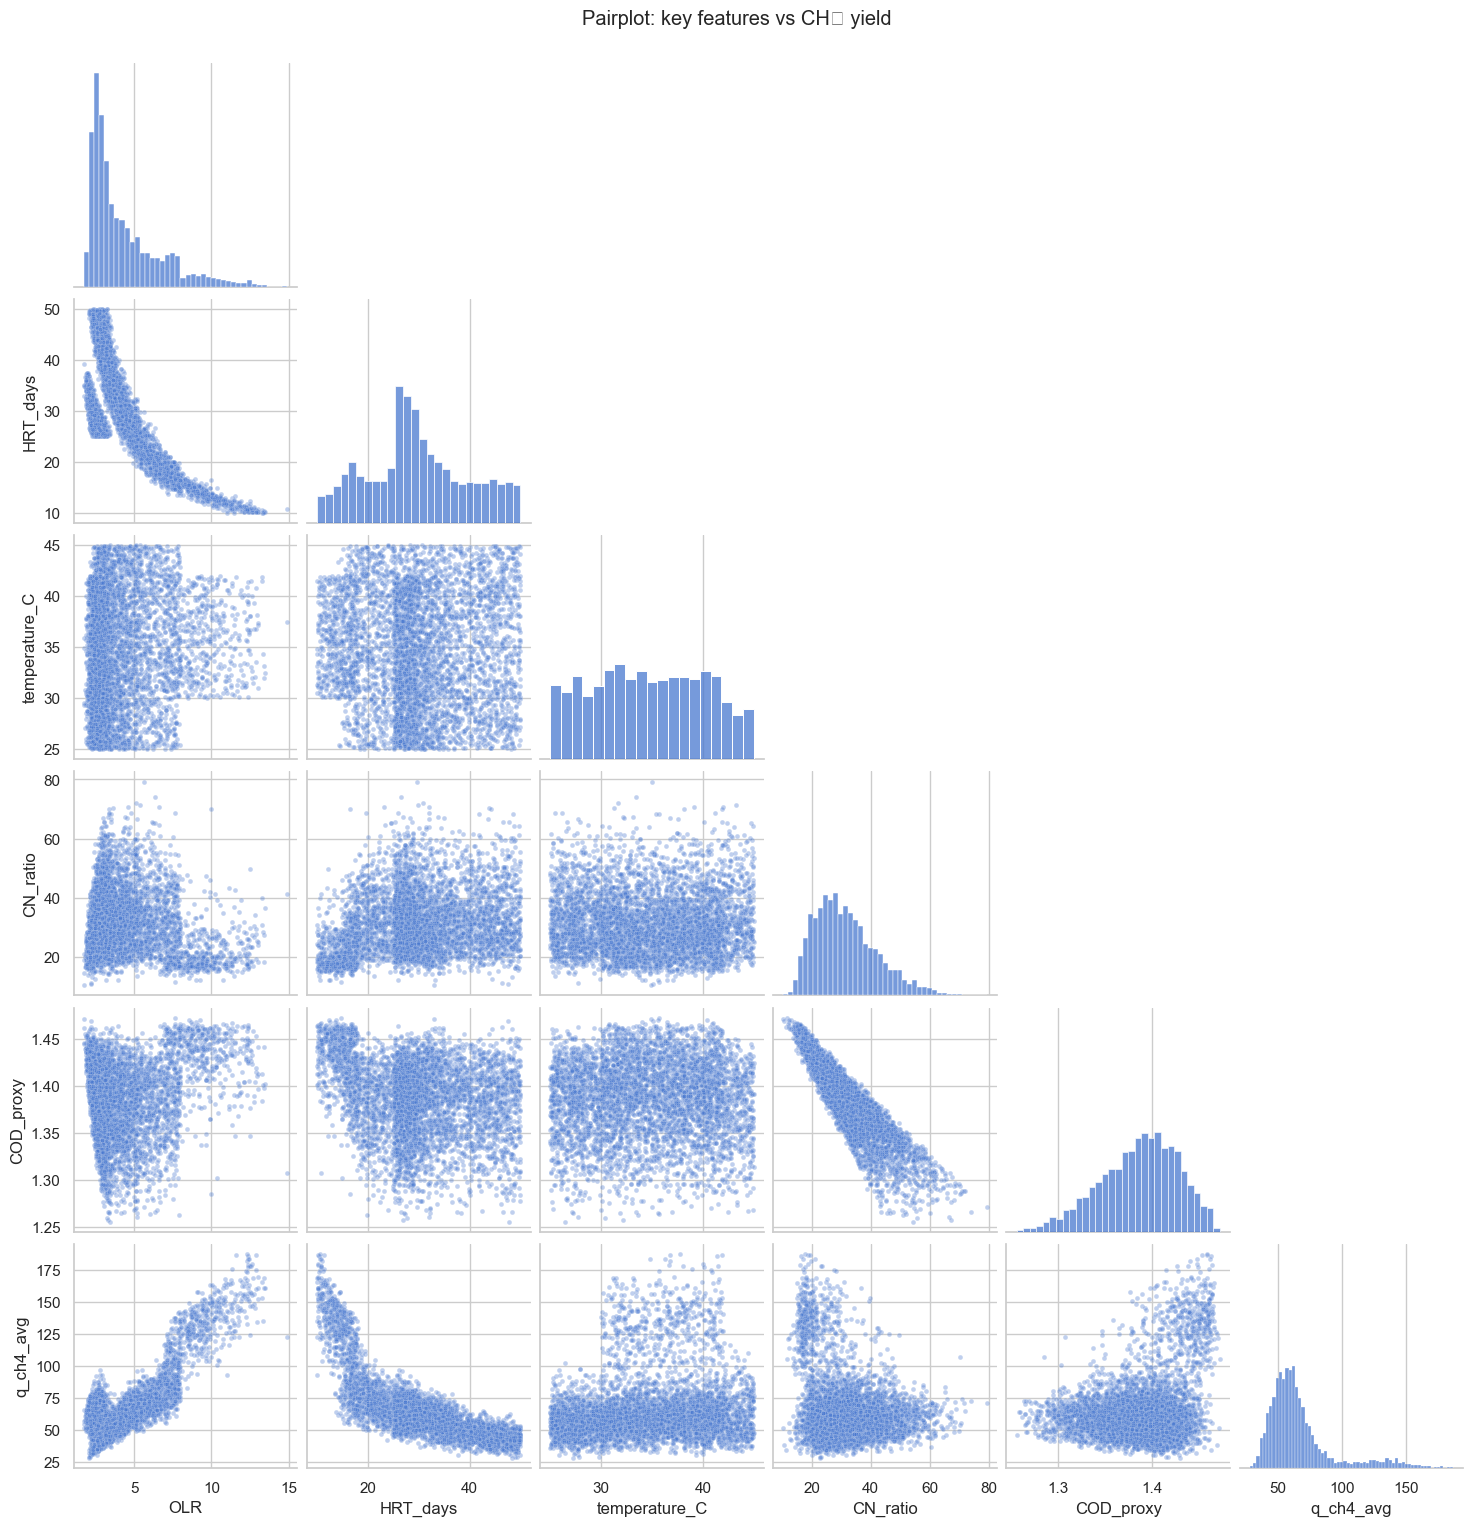

In [10]:
pair_cols = ["OLR", "HRT_days", "temperature_C", "CN_ratio", "COD_proxy", "q_ch4_avg"]
pair_df = X[[c for c in pair_cols if c in X.columns]].copy()
pair_df["q_ch4_avg"] = df["q_ch4_avg"].values
g = sns.pairplot(pair_df.dropna(), corner=True, plot_kws={"alpha": 0.35, "s": 12})
g.fig.suptitle("Pairplot: key features vs CH₄ yield", y=1.02)
plt.show()

## 9. Summary statistics

In [11]:
X.describe().round(3)

,cow_frac,rice_frac,wheat_frac,food_frac,press_frac,poultry_frac,temperature_C,HRT_days,OLR,CN_ratio,...,temp_HRT,lipid_frac_mix,protein_frac_mix,COD_proxy,OLR_x_food_frac,protein_to_CN,OLR_per_HRT,lipid_x_temp,q_ch4_avg,stability_label
count,4700.000,4700.000,4700.000,4700.000,4700.000,4700.000,4700.000,4700.000,4700.000,4700.000,...,4700.000,4700.000,4700.000,4700.000,4700.000,4700.000,4700.000,4700.000,4700.000,4700.000
mean,0.216,0.146,0.146,0.249,0.111,0.132,34.660,29.672,4.382,31.777,...,1026.816,0.087,0.180,1.386,1.291,0.007,0.202,3.013,66.846,0.005
std,0.162,0.134,0.134,0.199,0.116,0.123,5.446,9.853,2.333,10.572,...,385.273,0.021,0.041,0.041,1.786,0.004,0.217,0.880,26.550,0.073
min,0.000,0.000,0.000,0.000,0.000,0.000,25.011,10.000,1.745,10.497,...,305.431,0.030,0.070,1.256,0.000,0.001,0.042,0.812,27.951,0.000
25%,0.086,0.041,0.040,0.095,0.023,0.035,30.236,23.202,2.667,23.833,...,747.097,0.072,0.151,1.358,0.332,0.004,0.078,2.373,50.597,0.000
50%,0.186,0.108,0.109,0.199,0.072,0.096,34.525,28.766,3.456,30.127,...,978.224,0.086,0.180,1.390,0.674,0.006,0.106,2.939,60.127,0.000
75%,0.318,0.214,0.215,0.353,0.164,0.194,39.294,36.272,5.423,37.987,...,1249.193,0.100,0.207,1.417,1.275,0.009,0.232,3.579,72.074,0.000
max,0.851,0.808,0.851,0.959,0.823,0.847,44.995,49.989,14.899,79.233,...,2235.374,0.147,0.327,1.472,11.572,0.031,1.392,6.108,187.005,1.000


## 10. OLR_used vs OLR (before/after HRT-first sweep)

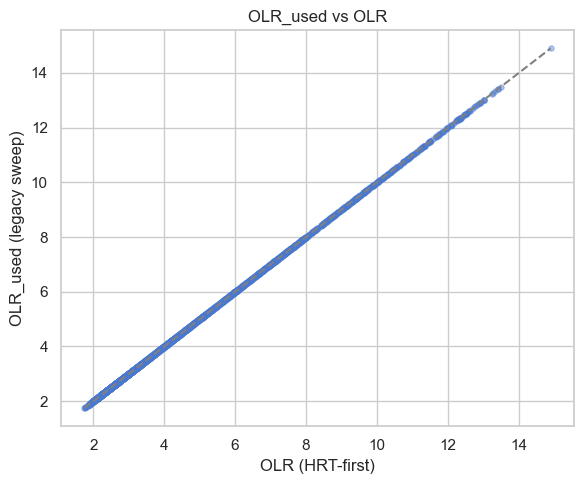

OLR_used and OLR are identical (expected for new HRT-first CSV).


In [12]:
if "OLR_used" in df.columns and "OLR" in df.columns:
    diff = (df["OLR_used"] - df["OLR"]).abs()
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(df["OLR"], df["OLR_used"], alpha=0.4, s=14)
    lo = min(df["OLR"].min(), df["OLR_used"].min())
    hi = max(df["OLR"].max(), df["OLR_used"].max())
    ax.plot([lo, hi], [lo, hi], "--", color="gray")
    ax.set_xlabel("OLR (HRT-first)")
    ax.set_ylabel("OLR_used (legacy sweep)")
    ax.set_title("OLR_used vs OLR")
    plt.tight_layout()
    plt.show()
    if diff.max() < 1e-6:
        print("OLR_used and OLR are identical (expected for new HRT-first CSV).")
    else:
        print(f"Max |OLR_used - OLR| = {diff.max():.3f} — legacy inflation visible on old sweeps.")
else:
    print("Only one OLR column present; no comparison plot needed.")

---

# Part 3 — Model training & literature validation

Mirrors `scripts/train_models.py` with figures. Deploy models with:
`python scripts/train_models.py --csv data/generated/biogas_training_merged.csv`

## 1. Load data

In [2]:
df, X, y_yield, y_health = tm._load_data(CSV_PATH)
X_df = pd.DataFrame(X, columns=feat_mod.FEATURE_COLUMNS)
print(f"Usable rows: {len(df)}")
print("Stability:", df["stability_label"].value_counts().sort_index().to_dict())
if "OLR" in df.columns:
    print(f"OLR: {df['OLR'].min():.2f} – {df['OLR'].max():.2f}")


Usable rows: 4700
Stability: {0: 4675, 1: 25}
OLR: 1.74 – 14.90


## 2. Train / test split

In [3]:
try:
    X_train, X_test, y_tr, y_te, h_tr, h_te = train_test_split(
        X, y_yield, y_health, test_size=0.15, random_state=SEED, stratify=y_health
    )
except ValueError:
    X_train, X_test, y_tr, y_te, h_tr, h_te = train_test_split(
        X, y_yield, y_health, test_size=0.15, random_state=SEED
    )
X_train_df = pd.DataFrame(X_train, columns=feat_mod.FEATURE_COLUMNS)
X_test_df = pd.DataFrame(X_test, columns=feat_mod.FEATURE_COLUMNS)
print(f"Train {len(X_train)}, Test {len(X_test)}, Features {X.shape[1]}")

Train 3995, Test 705, Features 19


## 3. Regressor comparison (5-fold CV)

In [4]:
reg_comparison = {}
best_reg_name, best_reg_cv = None, -1e9
for name in tm.REGRESSOR_NAMES:
    model = tm._make_regressor(name, SEED)
    metrics = tm._cv_regressor(model, X, y_yield, SEED, CV_FOLDS)
    reg_comparison[name] = metrics
    print(f"{name:14s}  CV R² = {metrics['cv_r2_mean']:.4f} ± {metrics['cv_r2_std']:.4f}")
    if metrics["cv_r2_mean"] > best_reg_cv:
        best_reg_cv = metrics["cv_r2_mean"]
        best_reg_name = name
print(f"\nBest regressor: {best_reg_name}")

xgboost         CV R² = 0.9981 ± 0.0002


lightgbm        CV R² = 0.9977 ± 0.0003


random_forest   CV R² = 0.9939 ± 0.0006


stacking        CV R² = 0.9100 ± 0.0095

Best regressor: xgboost


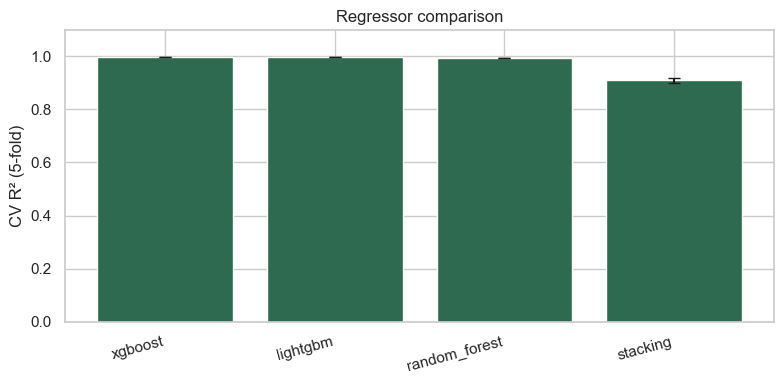

In [5]:
names = list(reg_comparison.keys())
means = [reg_comparison[n]["cv_r2_mean"] for n in names]
stds = [reg_comparison[n]["cv_r2_std"] for n in names]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(names))
ax.bar(x, means, yerr=stds, capsize=4, color="#2d6a4f", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha="right")
ax.set_ylabel("CV R² (5-fold)")
ax.set_title("Regressor comparison")
ax.set_ylim(0, max(1.0, max(means) + 0.1))
plt.tight_layout()
plt.show()

## 4. Train best regressor — hold-out scatter

In [6]:
reg = tm._make_regressor(best_reg_name, SEED)
reg.fit(X_train, y_tr)
pred = reg.predict(X_test)
r2 = r2_score(y_te, pred)
rmse = float(np.sqrt(mean_squared_error(y_te, pred)))
print(f"Hold-out R² = {r2:.4f}, RMSE = {rmse:.4f}")

Hold-out R² = 0.9981, RMSE = 1.0311


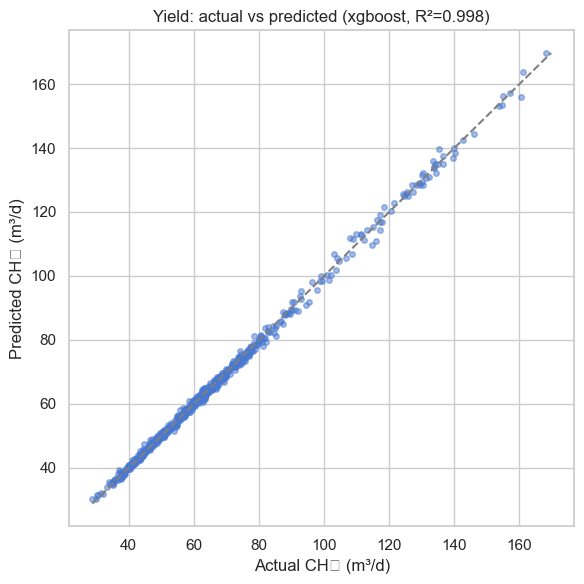

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_te, pred, alpha=0.5, s=16)
lo, hi = min(y_te.min(), pred.min()), max(y_te.max(), pred.max())
ax.plot([lo, hi], [lo, hi], "--", color="gray")
ax.set_xlabel("Actual CH₄ (m³/d)")
ax.set_ylabel("Predicted CH₄ (m³/d)")
ax.set_title(f"Yield: actual vs predicted ({best_reg_name}, R²={r2:.3f})")
plt.tight_layout()
plt.show()

## 5. Classifier comparison (5-fold CV + SMOTE)

In [8]:
clf_comparison = {}
best_clf_name, best_clf_cv = None, -1e9
for name in tm.CLASSIFIER_NAMES:
    model = tm._make_classifier(name, SEED)
    metrics = tm._cv_classifier(model, X, y_health, SEED, CV_FOLDS)
    clf_comparison[name] = metrics
    print(f"{name:14s}  CV F1-macro = {metrics['cv_f1_macro_mean']:.4f} ± {metrics['cv_f1_macro_std']:.4f}")
    if metrics["cv_f1_macro_mean"] > best_clf_cv:
        best_clf_cv = metrics["cv_f1_macro_mean"]
        best_clf_name = name
print(f"\nBest classifier: {best_clf_name}")

xgboost         CV F1-macro = 0.8318 ± 0.0329


lightgbm        CV F1-macro = 0.8190 ± 0.0828


random_forest   CV F1-macro = 0.7671 ± 0.0634


stacking        CV F1-macro = 0.7649 ± 0.1474

Best classifier: xgboost


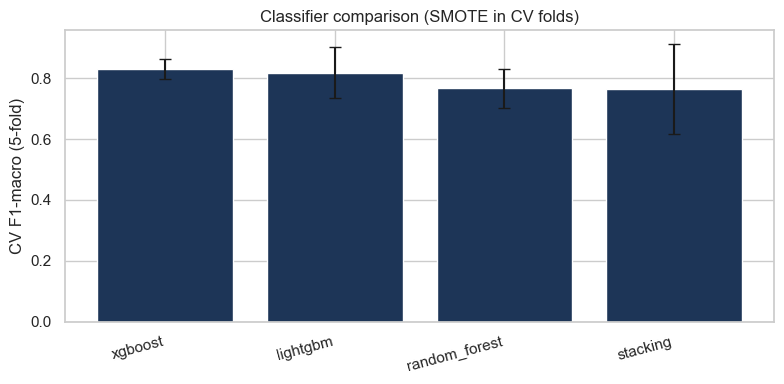

In [9]:
names = list(clf_comparison.keys())
means = [clf_comparison[n]["cv_f1_macro_mean"] for n in names]
stds = [clf_comparison[n]["cv_f1_macro_std"] for n in names]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(names))
ax.bar(x, means, yerr=stds, capsize=4, color="#1d3557", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha="right")
ax.set_ylabel("CV F1-macro (5-fold)")
ax.set_title("Classifier comparison (SMOTE in CV folds)")
plt.tight_layout()
plt.show()

## 6. Train best classifier — confusion matrix & report

In [10]:
clf = tm._make_classifier(best_clf_name, SEED)
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline

    kn = min(3, int(np.bincount(h_tr).min()) - 1)
    clf_pipe = ImbPipeline([
        ("smote", SMOTE(random_state=SEED, k_neighbors=max(1, kn))),
        ("clf", clf),
    ])
    clf_pipe.fit(X_train, h_tr)
    hp = tm._safe_predict(clf_pipe, X_test)
    clf_for_shap = clf_pipe.named_steps["clf"]
except Exception as exc:
    print(f"SMOTE unavailable ({exc}); fitting without oversampling.")
    clf.fit(X_train, h_tr)
    hp = tm._safe_predict(clf, X_test)
    clf_for_shap = clf

all_health_labels = sorted(np.unique(y_health))
f1 = f1_score(h_te, hp, average="macro", labels=all_health_labels, zero_division=0)
print(classification_report(
    h_te, hp, digits=3, labels=all_health_labels,
    target_names=["Stable", "Warning", "Critical"][: len(all_health_labels)],
))
print(f"F1-macro = {f1:.4f}")

              precision    recall  f1-score   support

      Stable      1.000     0.999     0.999       701
     Warning      0.800     1.000     0.889         4

    accuracy                          0.999       705
   macro avg      0.900     0.999     0.944       705
weighted avg      0.999     0.999     0.999       705

F1-macro = 0.9441


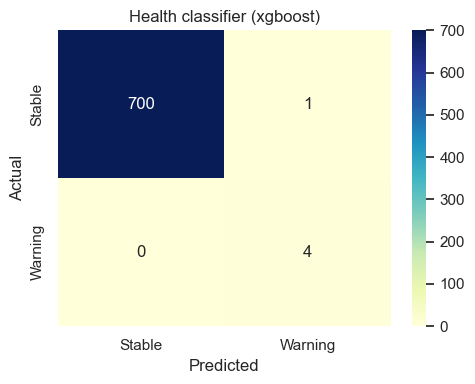

In [11]:
label_names = ["Stable", "Warning", "Critical"]
present = sorted(np.unique(np.concatenate([h_te, hp])))
cm = confusion_matrix(h_te, hp, labels=present)
tick = [label_names[i] if i < len(label_names) else str(i) for i in present]
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", xticklabels=tick, yticklabels=tick, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Health classifier ({best_clf_name})")
plt.tight_layout()
plt.show()

## 7. SHAP explainability

SHAP — yield regressor


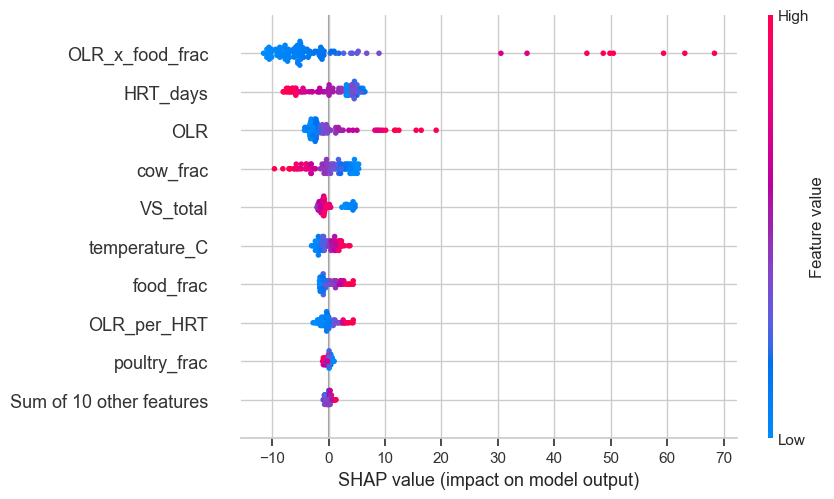

SHAP — health classifier (Warning class; XGBoost is multi-class)


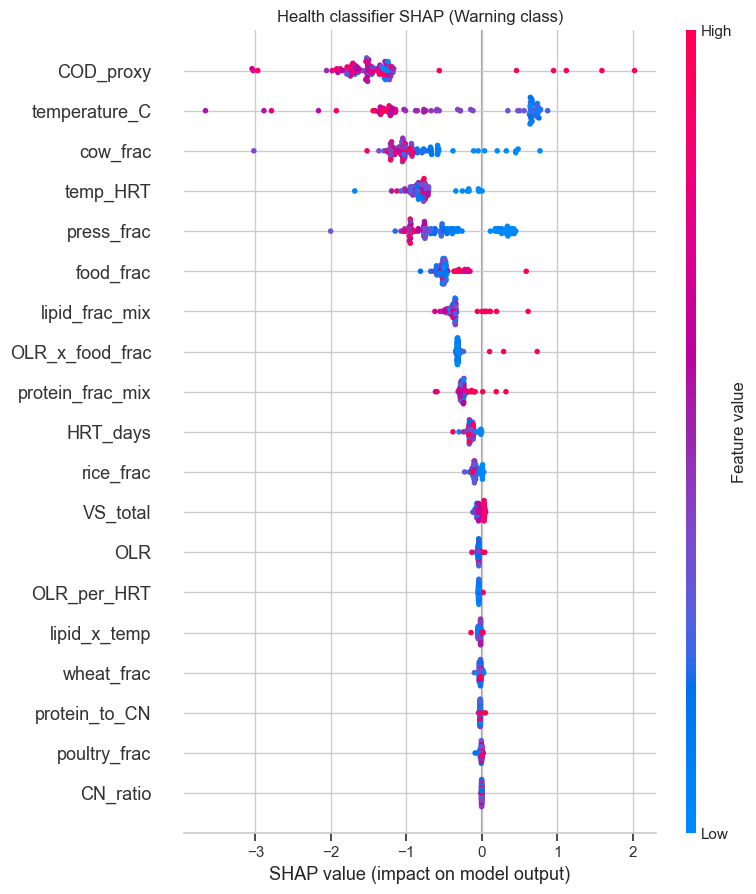

In [12]:
bg = X_train_df.sample(n=min(100, len(X_train_df)), random_state=SEED)
feat_names = list(bg.columns)

print("SHAP — yield regressor")
exp_reg = shap.Explainer(reg, bg.values, feature_names=feat_names)
sv_reg = exp_reg(bg.values)
shap.plots.beeswarm(sv_reg, show=True)

print("SHAP — health classifier (Warning class; XGBoost is multi-class)")
explainer_clf = shap.TreeExplainer(clf_for_shap)
sv_clf_all = explainer_clf.shap_values(bg.values)
if isinstance(sv_clf_all, list):
    cls_idx = 1 if len(sv_clf_all) > 1 else 0
    shap.summary_plot(sv_clf_all[cls_idx], bg.values, feature_names=feat_names, show=False)
    plt.title(f"Health classifier SHAP (class index {cls_idx})")
elif isinstance(sv_clf_all, np.ndarray) and sv_clf_all.ndim == 3:
    shap.summary_plot(sv_clf_all[:, :, 1], bg.values, feature_names=feat_names, show=False)
    plt.title("Health classifier SHAP (Warning class)")
else:
    shap.summary_plot(sv_clf_all, bg.values, feature_names=feat_names, show=False)
    plt.title("Health classifier SHAP")
plt.tight_layout()
plt.show()

## 8. Learning curve (is 3000 samples enough?)

,fraction,n_train,r2
0,0.2,940,0.9938
1,0.4,1880,0.9962
2,0.6,2820,0.9975
3,0.8,3760,0.9983
4,1.0,4700,0.9999


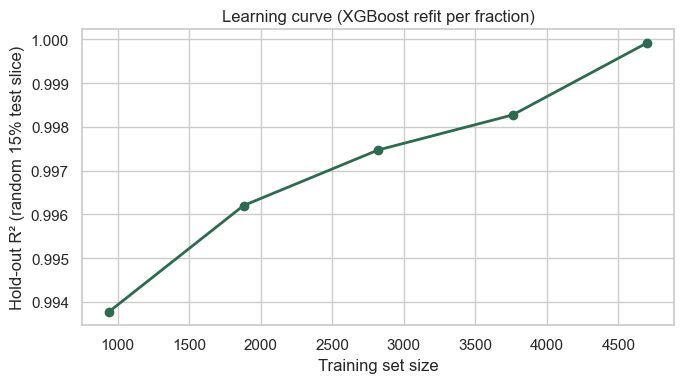

In [13]:
lc = tm._learning_curve_regressor(reg, X, y_yield, SEED)
lc_df = pd.DataFrame(lc)
display(lc_df.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lc_df["n_train"], lc_df["r2"], "o-", color="#2d6a4f", lw=2)
ax.set_xlabel("Training set size")
ax.set_ylabel("Hold-out R² (random 15% test slice)")
ax.set_title("Learning curve (XGBoost refit per fraction)")
plt.tight_layout()
plt.show()

## 9. Literature validation (in-range + bias correction)

Training ranges: {'temperature_C': (25.01136258517889, 44.99530673828688), 'HRT_days': (10.000219386201556, 49.988594042515714), 'OLR': (1.7447862257079942, 14.8994967816578)}
In-range: 19 / 21  |  Excluded: 2


,substrate_desc,temperature_C,HRT_days,OLR
1,Cow dung mono-digestion (thermophilic),53.0,25.0,2.0
6,"Cattle dung only (35C, continuous)",35.0,35.0,1.5


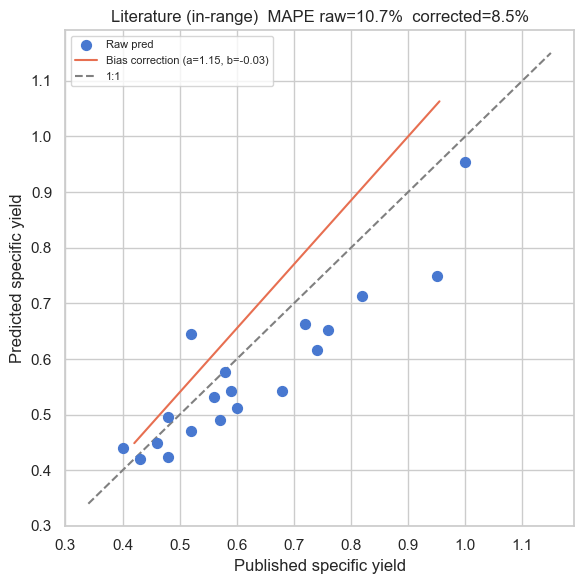

In [14]:
lit_csv = ROOT / "data" / "validation" / "literature_points.csv"
training_ranges = {
    "temperature_C": (float(df["temperature_C"].min()), float(df["temperature_C"].max())),
    "HRT_days": (float(df["HRT_days"].min()), float(df["HRT_days"].max())),
    "OLR": (float(df["OLR"].min()), float(df["OLR"].max())) if "OLR" in df.columns else (0.5, 8.0),
}
print("Training ranges:", training_ranges)

if not lit_csv.is_file():
    print(f"Missing {lit_csv}")
else:
    lit = pd.read_csv(lit_csv)
    preds, in_range = [], []
    for _, row in lit.iterrows():
        temp, hrt, olr = float(row["temperature_C"]), float(row["HRT_days"]), float(row["OLR"])
        ok = (
            training_ranges["temperature_C"][0] <= temp <= training_ranges["temperature_C"][1]
            and training_ranges["HRT_days"][0] <= hrt <= training_ranges["HRT_days"][1]
            and training_ranges["OLR"][0] <= olr <= training_ranges["OLR"][1]
        )
        in_range.append(ok)
        feat_row = {
            "cow_frac": float(row["cow_frac"]),
            "rice_frac": float(row["rice_frac"]),
            "wheat_frac": float(row["wheat_frac"]),
            "food_frac": float(row["food_frac"]),
            "press_frac": float(row["press_frac"]),
            "poultry_frac": float(row["poultry_frac"]),
            "temperature_C": temp,
            "HRT_days": hrt,
            "OLR": olr,
        }
        preds.append(float(reg.predict(feat_mod.feature_matrix(feat_row))[0]) / V_LIQ)

    lit = lit.copy()
    lit["predicted"] = preds
    lit["in_training_range"] = in_range
    lit["pct_error"] = np.abs(lit["observed_specific_yield"] - lit["predicted"]) / np.maximum(lit["observed_specific_yield"], 1e-6) * 100

    lit_eval = lit[lit["in_training_range"]].copy()
    excluded = lit[~lit["in_training_range"]]
    print(f"In-range: {len(lit_eval)} / {len(lit)}  |  Excluded: {len(excluded)}")
    if len(excluded):
        display(excluded[["substrate_desc", "temperature_C", "HRT_days", "OLR"]])

    obs = lit_eval["observed_specific_yield"].values
    pred_arr = lit_eval["predicted"].values
    mape_raw = float(lit_eval["pct_error"].mean()) if len(lit_eval) else float("nan")
    a, b = 1.0, 0.0
    if len(obs) >= 3:
        A = np.column_stack([pred_arr, np.ones(len(pred_arr))])
        coef, _, _, _ = np.linalg.lstsq(A, obs, rcond=None)
        a, b = float(coef[0]), float(coef[1])
    pred_corr = a * pred_arr + b
    mape_corr = float(np.mean(np.abs(obs - pred_corr) / np.maximum(obs, 1e-6) * 100)) if len(obs) else float("nan")

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(obs, pred_arr, s=50, label="Raw pred", zorder=5)
    xline = np.linspace(pred_arr.min(), pred_arr.max(), 50)
    ax.plot(xline, a * xline + b, "-", color="#e76f51", label=f"Bias correction (a={a:.2f}, b={b:.2f})")
    lo = min(obs.min(), pred_arr.min()) * 0.85
    hi = max(obs.max(), pred_arr.max()) * 1.15
    ax.plot([lo, hi], [lo, hi], "--", color="gray", label="1:1")
    ax.set_xlabel("Published specific yield")
    ax.set_ylabel("Predicted specific yield")
    ax.set_title(f"Literature (in-range)  MAPE raw={mape_raw:.1f}%  corrected={mape_corr:.1f}%")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 10. Literature per-point table

In [15]:
if lit_csv.is_file():
    cols = ["source", "substrate_desc", "observed_specific_yield", "predicted", "pct_error", "in_training_range"]
    display(lit[cols].round(3))

,source,substrate_desc,observed_specific_yield,predicted,pct_error,in_training_range
0,"MDPI Bioengineering 2022, Table 2",Cow dung mono-digestion (mesophilic),0.40,0.439,9.823,True
1,"MDPI Bioengineering 2022, Table 2",Cow dung mono-digestion (thermophilic),0.36,0.462,28.282,False
2,"Frontiers Energy Res. 2025, Table 3","Food waste + cow dung (70:30, 37C)",0.95,0.749,21.131,True
3,"Frontiers Energy Res. 2025, Table 3","Food waste + cow dung (50:50, 37C)",0.76,0.652,14.153,True
4,"Frontiers Energy Res. 2025, Table 3","Food waste + cow dung (30:70, 37C)",0.59,0.543,7.932,True
5,"IJERT 2020, Table 1","Kitchen waste + cattle dung (1:1, 35C)",0.58,0.576,0.708,True
6,"IJERT 2020, Table 1","Cattle dung only (35C, continuous)",0.30,0.355,18.186,False
7,"Springer AAER 2023, Table 2","Cow dung + market waste (50:50, Delhi)",0.82,0.713,13.089,True
8,"Indian J. Anim. Sci. 2019, Fig 3","Rice straw + cow dung (40:60, 37C)",0.46,0.449,2.343,True
9,"Indian J. Anim. Sci. 2019, Fig 3","Rice straw + cow dung (20:80, 37C)",0.43,0.420,2.216,True


## Summary

| Metric | Value |
|--------|-------|
| Best regressor (CV R²) | See bar chart above |
| Hold-out yield R² / RMSE | Printed in section 4 |
| Best classifier (CV F1-macro) | See bar chart above |
| Hold-out health F1-macro | Printed in section 6 |
| Literature MAPE (in-range) | Raw vs bias-corrected in section 9 |

Deploy models with: `python scripts/train_models.py`

## 10. Deployment notes (web app)

- **Yield:** `src/optimizer.py` applies literature bias correction (`src/calibration.py`) at inference — same OLS as section 9.
- **Health:** Rule-based stability from estimated pH/VFA (OLR, HRT, feed mix), not the ML classifier (training data had 100% Stable).
- **UI sliders:** OLR 2.0–6.0, HRT 10–50 d (see `src/calibration.py`).
- **Supplementary sweeps:** `scripts/generate_supplementary_sweeps.py` (low OLR + instability) → `scripts/merge_training_csvs.py` → retrain.

## 11. Thesis-ready export (run after training)

Saves parity and learning-curve figures under `models/thesis_figures/` when `literature_validation.json` and `eval_metrics.json` exist.

In [16]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

fig_dir = ROOT / "models" / "thesis_figures"
fig_dir.mkdir(parents=True, exist_ok=True)

em = json.loads((ROOT / "models" / "eval_metrics.json").read_text(encoding="utf-8"))
lc = em.get("learning_curve") or []
if lc:
    fr = [x["fraction"] for x in lc]
    r2 = [x["r2"] for x in lc]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(fr, r2, "o-", color="#2d6a4f", lw=2)
    ax.set_xlabel("Training fraction")
    ax.set_ylabel("Hold-out R²")
    ax.set_title("Learning curve (yield regressor)")
    ax.grid(True, alpha=0.3)
    fig.savefig(fig_dir / "learning_curve.png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    print("Saved learning_curve.png")

lv = ROOT / "models" / "literature_validation.json"
if lv.is_file():
    data = json.loads(lv.read_text(encoding="utf-8"))
    pts = pd.DataFrame(data["per_point"])
    bc = (data.get("overall_in_range") or {}).get("bias_correction") or {}
    ba, bb = float(bc.get("a", 1)), float(bc.get("b", 0))
    if "predicted" in pts.columns:
        pts["pred_corr"] = ba * pts["predicted"] + bb
    fig, ax = plt.subplots(figsize=(6, 6))
    if "in_training_range" in pts.columns:
        ex, inn = pts[~pts["in_training_range"]], pts[pts["in_training_range"]]
        ax.scatter(ex["observed"], ex["predicted"], c="#94a3b8", s=60, label="Out of range", alpha=0.8)
        ax.scatter(inn["observed"], inn["pred_corr"], c="#2d6a4f", s=60, label="In range (corrected)")
    else:
        ax.scatter(pts["observed"], pts["predicted"], c="#2d6a4f", s=60)
    lo = min(pts["observed"].min(), pts.get("pred_corr", pts["predicted"]).min()) * 0.85
    hi = max(pts["observed"].max(), pts.get("pred_corr", pts["predicted"]).max()) * 1.15
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.5)
    ax.set_xlabel("Published specific CH₄ yield")
    ax.set_ylabel("BioOptima (bias-corrected)")
    ax.legend()
    ax.set_title("Literature validation (21 points)")
    fig.savefig(fig_dir / "literature_parity.png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    print("Saved literature_parity.png")

Saved learning_curve.png


Saved literature_parity.png
